# Notebook 02.2 — Imputação de Classes Viárias (GNN + baseline Random Forest)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI
**Autor:** Felipe Ramos Dantas
**Orientador:** Prof. Dr. Antonio Joaquim da Silva
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs
**Apêndice:** E · **Última atualização:** 2026-06-12

---

## Objetivo
Imputar a classe funcional das vias rotuladas como `unknown`/`unclassified` (lacunas que
impedem a atribuição de velocidade no NB 03), usando uma Rede Neural em Grafos (GraphSAGE).
Um modelo Random Forest serve de **linha de base** para justificar metodologicamente a
escolha do modelo final (comparação por F1-score).

## Entrada
| Arquivo | Origem |
|---|---|
| `dados/intermediarios/02_grafo/zonaUrbana_5km_road_cleaned.parquet` | NB 02.1 |

## Saída
| Arquivo | Consumido por |
|---|---|
| `dados/intermediarios/02_grafo/zonaUrbana_5km_road_imputed.parquet` | NB 03 (impedâncias) |

## Pré-requisitos
- NB 02.1 executado. Ambiente `.venv` com `torch`, `torch_geometric`, `city2graph`, `momepy`.
---

## 1. Configuração e importações

Bibliotecas de aprendizado de máquina (scikit-learn, PyTorch Geometric, city2graph) e *helpers* do projeto; criação das subpastas de saída (`nb022`).

In [1]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO ───────────────────────────────────────────
import warnings
from collections import defaultdict

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.utils.class_weight import compute_class_weight

from mapeprof.config import (
    CRS_METRICO,
    EXT_IBGE,
    FIGURAS,
    INT_GRAFO,
    TABELAS,
    criar_diretorios,
)
from mapeprof.viz import (
    ajustar_zoom_camada,
    aplicar_estilo,
    barra_escala,
    formatar_eixos_mapa,
    moldura_mapa,
    seta_norte,
)

aplicar_estilo()
warnings.filterwarnings("ignore")
criar_diretorios()
FIGURAS_NB = FIGURAS / "nb022"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)

TABELAS_NB = TABELAS / "nb022"; TABELAS_NB.mkdir(parents=True, exist_ok=True)

print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Carga e engenharia de atributos

O modelo aprende com dois tipos de informação por via:
- **Atributos intrínsecos** já preparados no NB 02.1: comprimento (`length_m`),
  linearidade e pavimentação.
- **Atributos de posição na rede (centralidade)**, calculados aqui sobre o **grafo dual**
  (cada via vira um nó; vias que compartilham uma extremidade são vizinhas). A literatura
  mostra que a centralidade é mais preditiva da hierarquia viária que a geometria pura.

Calculamos duas medidas de centralidade:
- **Grau** — número de vias conectadas (conectividade local).
- **Intermediação (*betweenness*)** — frequência com que a via está nos caminhos mais
  curtos da rede; vias "de passagem" tendem a ser arteriais. Usamos a versão **aproximada**
  (amostragem de 400 nós) — a exata é inviável neste tamanho de rede.  

In [2]:
# ── 2. CARGA, GRAFO DUAL E FEATURES ─────────────────────────────────────────
gdf = gpd.read_parquet(INT_GRAFO / "zonaUrbana_5km_road_cleaned.parquet").reset_index(drop=True)
print(f"🔄 {len(gdf):,} arestas carregadas.")

# Grafo dual: via = nó; extremidade compartilhada = vizinhança (line graph)
pontas_para_vias = defaultdict(list)
for i, geom in zip(gdf.index, gdf.geometry):
    pontas_para_vias[geom.coords[0]].append(i)
    pontas_para_vias[geom.coords[-1]].append(i)

D = nx.Graph()
D.add_nodes_from(gdf.index)
for vias in pontas_para_vias.values():
    for a in range(len(vias)):
        for b in range(a + 1, len(vias)):
            D.add_edge(vias[a], vias[b])
print(f"🕸️ Grafo dual: {D.number_of_nodes():,} nós, {D.number_of_edges():,} arestas.")

# Features de centralidade (betweenness aproximada ~80 s)
print("⚙️ Calculando centralidade (~80 s)...")
gdf["grau"]        = pd.Series(dict(D.degree())).astype(float)
gdf["betweenness"] = pd.Series(nx.betweenness_centrality(D, k=400, seed=42))
gdf["is_paved"]    = (gdf["surf_group"] == "Pavimentada").astype(int)

FEATURES = ["length_m", "linearity", "grau", "betweenness", "is_paved"]

# Separação treino (classe conhecida) vs alvo (a imputar)
CLASSES_ALVO = ["unknown", "unclassified"]
gdf["is_alvo"] = gdf["class"].isin(CLASSES_ALVO)
print(f"📊 Treino: {(~gdf['is_alvo']).sum():,} | Alvo (imputar): {gdf['is_alvo'].sum():,}")
print(gdf[FEATURES].describe().round(3))

🔄 52,977 arestas carregadas.
🕸️ Grafo dual: 52,977 nós, 119,538 arestas.
⚙️ Calculando centralidade (~80 s)...
📊 Treino: 51,337 | Alvo (imputar): 1,640
        length_m  linearity       grau  betweenness   is_paved
count  52977.000  52977.000  52977.000    52977.000  52977.000
mean      90.940      0.985      4.513        0.002      0.256
std      115.350      0.078      1.075        0.008      0.436
min        0.000      0.000      0.000        0.000      0.000
25%       40.739      1.000      4.000        0.000      0.000
50%       66.962      1.000      4.000        0.000      0.000
75%      110.513      1.000      5.000        0.000      1.000
max     4780.985      1.000     10.000        0.179      1.000


## 3. Linha de base: Random Forest

Antes da GNN, treinamos um Random Forest sobre as mesmas features. Ele **não enxerga a
vizinhança** (cada via é classificada isoladamente), servindo como piso de desempenho:
a GNN só se justifica se superá-lo.

Diante do forte desbalanceamento (a classe `residential` domina), usamos
`class_weight="balanced"` (peso inversamente proporcional à frequência), para o modelo
não ignorar as classes minoritárias (vias arteriais). A avaliação é por **validação
cruzada estratificada de 5 dobras**, reportando o **F1-score por classe**.

In [3]:
# ── 3. BASELINE RANDOM FOREST (validação cruzada 5-fold) ────────────────────
X = gdf.loc[~gdf["is_alvo"], FEATURES].to_numpy(dtype=float)
y = gdf.loc[~gdf["is_alvo"], "class"].astype(str).to_numpy()

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                            n_jobs=-1, random_state=42)
y_pred = cross_val_predict(rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))

f1_macro_rf    = f1_score(y, y_pred, average="macro")
f1_weighted_rf = f1_score(y, y_pred, average="weighted")
print(f"🌲 RF — F1 macro: {f1_macro_rf:.3f} | F1 weighted: {f1_weighted_rf:.3f}")
print("\n--- F1 por classe ---")
print(pd.DataFrame(classification_report(y, y_pred, zero_division=0, output_dict=True))
      .T[["f1-score", "support"]].round(3).to_string())

# Importância das features — evidência de que a centralidade é preditiva
rf.fit(X, y)
importancia = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\n--- Importância das features ---")
print(importancia.round(3).to_string())

🌲 RF — F1 macro: 0.274 | F1 weighted: 0.557

--- F1 por classe ---
               f1-score   support
cycleway          0.369    166.00
footway           0.279    953.00
living_street     0.159    663.00
path              0.077    602.00
pedestrian        0.100     43.00
primary           0.276   2680.00
residential       0.697  34003.00
secondary         0.317   3087.00
service           0.417   4058.00
steps             0.327     26.00
tertiary          0.196   4299.00
track             0.101    272.00
trunk             0.242    485.00
accuracy          0.510      0.51
macro avg         0.274  51337.00
weighted avg      0.557  51337.00

--- Importância das features ---
length_m       0.401
betweenness    0.307
linearity      0.151
grau           0.091
is_paved       0.049


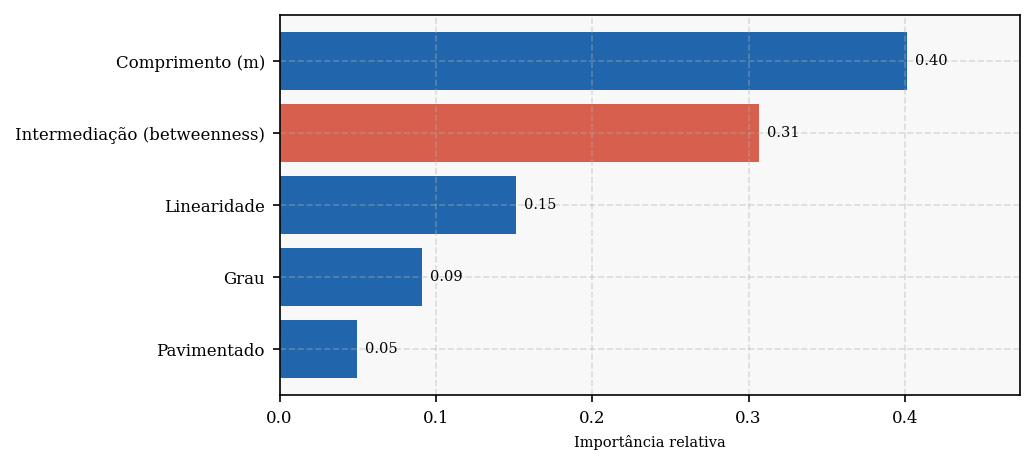

In [4]:
# ── Fig. 01 — Importância das features (Random Forest) ──────────────────────
TRADUCAO_FEATURES = {
    "length_m":    "Comprimento (m)",
    "linearity":   "Linearidade",
    "grau":        "Grau",
    "betweenness": "Intermediação (betweenness)",
    "is_paved":    "Pavimentado",
}

imp_ordenada = importancia.sort_values()   # menor → maior (maior no topo do gráfico)
cores = ["#D6604D" if f == "betweenness" else "#2166AC" for f in imp_ordenada.index]
rotulos = [TRADUCAO_FEATURES.get(f, f) for f in imp_ordenada.index]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(rotulos, imp_ordenada.values, color=cores)
for i, v in enumerate(imp_ordenada.values):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=7)
ax.set_xlim(0, imp_ordenada.max() * 1.18)
ax.set_xlabel("Importância relativa", fontsize=7)
# ax.set_title("Importância das features na classificação\n"
#              "(centralidade de rede em destaque)")
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb022_fig02_importancia_features.png", bbox_inches="tight")
plt.show()

## 4. Montagem do grafo para a Rede Neural (PyTorch Geometric)

A GNN aprende observando, para cada via, **suas próprias features e as das vias vizinhas**
(*message passing*) — é isso que o Random Forest não faz. Preparamos três peças:

- **Matriz de atributos (X)** — as mesmas features do baseline, agora **padronizadas**
  (média 0, desvio 1), pois redes neurais são sensíveis à escala.
- **Conectividade (`edge_index`)** — as arestas do grafo dual já construído, no formato
  de tensor exigido pelo PyTorch Geometric.
- **Rótulos (y) e máscaras** — as classes conhecidas são codificadas em números; as vias
  a imputar recebem -1 e ficam de fora do treino. Entre as conhecidas, separamos 80% para
  treino e 20% para teste (estratificado), para medir o desempenho de forma honesta.

In [5]:
# ── 4. CONSTRUÇÃO DO OBJETO Data (PyTorch Geometric) ────────────────────────
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

torch.manual_seed(42); np.random.seed(42)

# Atributos padronizados (exigência das redes neurais)
X_scaled = StandardScaler().fit_transform(gdf[FEATURES].to_numpy(float))

# edge_index: arestas do grafo dual em ambos os sentidos (grafo não-direcionado)
arestas_dual = np.array(list(D.edges())).T
edge_index = torch.tensor(np.concatenate([arestas_dual, arestas_dual[::-1]], axis=1),
                          dtype=torch.long)

# Codificação das classes conhecidas; alvos recebem -1
encoder = LabelEncoder().fit(gdf.loc[~gdf["is_alvo"], "class"].astype(str))
y = np.full(len(gdf), -1)
y[~gdf["is_alvo"].values] = encoder.transform(gdf.loc[~gdf["is_alvo"], "class"].astype(str))

# Split treino/teste entre as vias COM classe conhecida
idx_conhecidos = np.where(~gdf["is_alvo"].values)[0]
idx_treino, idx_teste = train_test_split(
    idx_conhecidos, test_size=0.2, random_state=42, stratify=y[idx_conhecidos])

data = Data(x=torch.tensor(X_scaled, dtype=torch.float),
            edge_index=edge_index, y=torch.tensor(y))
mask_treino = torch.zeros(len(gdf), dtype=bool); mask_treino[idx_treino] = True
mask_teste  = torch.zeros(len(gdf), dtype=bool); mask_teste[idx_teste]  = True

print(f"✅ Grafo PyG: {data.num_nodes:,} nós | {data.num_edges:,} conexões | "
      f"{len(encoder.classes_)} classes")
print(f"   Treino: {mask_treino.sum():,} | Teste: {mask_teste.sum():,} | "
      f"Alvos a imputar: {gdf['is_alvo'].sum():,}")

✅ Grafo PyG: 52,977 nós | 239,076 conexões | 13 classes
   Treino: 41,069 | Teste: 10,268 | Alvos a imputar: 1,640


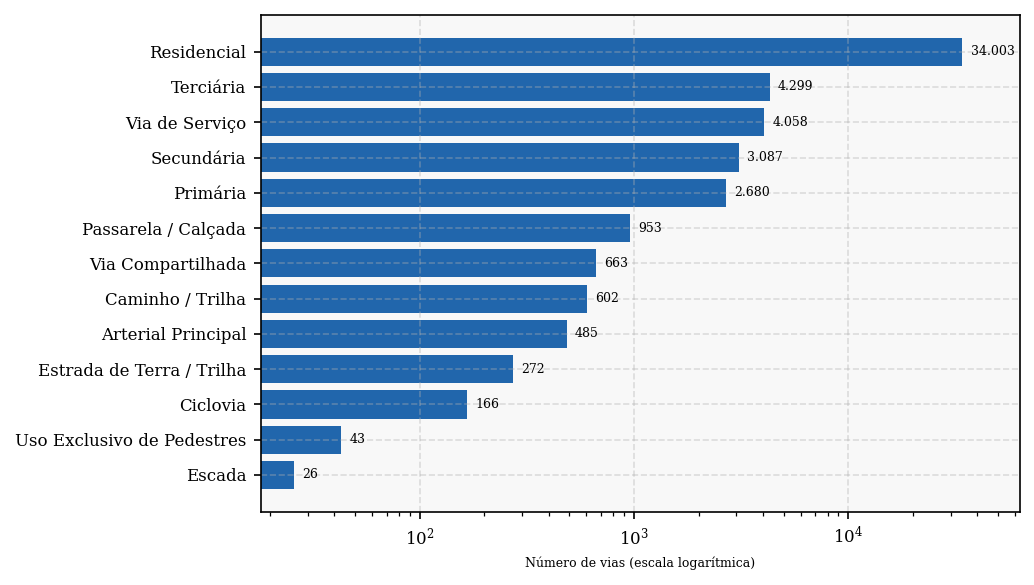

In [6]:
# ── Fig. 02 — Desbalanceamento das classes funcionais ───────────────────────
FONTE_ROTULO_BARRA = 6      # tamanho da fonte do valor ao final de cada barra
DESLOC_ROTULO_PX   = 4      # deslocamento horizontal do rótulo, em pixels (não em dado)

traducao_classes = {
    "motorway": "Via Expressa", "trunk": "Arterial Principal", "primary": "Primária",
    "secondary": "Secundária", "tertiary": "Terciária", "residential": "Residencial",
    "living_street": "Via Compartilhada", "pedestrian": "Uso Exclusivo de Pedestres",
    "footway": "Passarela / Calçada", "path": "Caminho / Trilha",
    "track": "Estrada de Terra / Trilha", "service": "Via de Serviço",
    "cycleway": "Ciclovia", "steps": "Escada", "road": "Via Genérica (não especificada)",
    "unclassified": "Não classificada", "unknown": "Desconhecida",
}

contagem_classes = gdf.loc[~gdf["is_alvo"], "class"].value_counts()
rotulos_classes = [traducao_classes.get(str(c).lower(), str(c).title())
                   for c in contagem_classes.index[::-1]]
valores = contagem_classes.values[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.barh(rotulos_classes, valores, color="#2166AC")

# rótulo do valor ao final de cada barra — offset em pontos, seguro em escala log
for barra, v in zip(barras, valores):
        ax.annotate(f"{v:,.0f}".replace(",", "."),
                xy=(barra.get_width(), barra.get_y() + barra.get_height() / 2),
                xytext=(DESLOC_ROTULO_PX, 0), textcoords="offset points",
                va="center", ha="left", fontsize=FONTE_ROTULO_BARRA)

ax.set_xscale("log")
ax.set_xlabel("Número de vias (escala logarítmica)", fontsize=6)
# ax.set_title("Distribuição das classes funcionais conhecidas\n"
#              "(domínio de 'Residencial' motiva o teste de balanceamento)")
ax.set_xlim(right=ax.get_xlim()[1] * 1.3)   # abre espaço à direita pros rótulos não cortarem
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb022_fig01_desbalanceamento_classes.png", bbox_inches="tight")
plt.show()

## 5. O efeito do balanceamento de classes (experimento metodológico)

A classe `residential` domina a rede (66% das vias). Diante disso, a prática comum é
**ponderar as classes pelo inverso da frequência** na função de perda, para o modelo não
ignorar as classes raras. Testamos as duas configurações — **com** e **sem** ponderação —
medindo não só o F1, mas também **a distribuição das classes imputadas** e a **velocidade
média** resultante. Como veremos, a ponderação melhora marginalmente o F1 macro, mas
**distorce gravemente a imputação**, inflando vias não pavimentadas e rebaixando as
velocidades — o que enviesaria todo o cálculo de acessibilidade (NB 03–05).

In [7]:
# ── 5. EXPERIMENTO: COM vs SEM PONDERAÇÃO DE CLASSES ────────────────────────
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

# Velocidades por classe (espelha o SPEED_DICT do NB 03) — para medir o impacto
SPEED_DICT = {'motorway':80,'trunk':70,'primary':60,'secondary':50,'tertiary':40,
              'residential':30,'living_street':20,'service':20,'track':20,
              'unclassified':30,'road':30,'pedestrian':5,'footway':5,'path':5,
              'steps':5,'cycleway':15}

class RoadSAGE(torch.nn.Module):
    """GraphSAGE de 2 camadas para classificação de nós (vias)."""
    def __init__(self, n_features, n_hidden, n_classes):
        super().__init__()
        self.conv1 = SAGEConv(n_features, n_hidden)
        self.conv2 = SAGEConv(n_hidden, n_classes)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.conv2(x, edge_index)

def treinar_gnn(ponderar, epocas=300):
    torch.manual_seed(42)
    modelo = RoadSAGE(len(FEATURES), 32, len(encoder.classes_))
    otim = torch.optim.Adam(modelo.parameters(), lr=0.01, weight_decay=5e-4)
    pesos = None
    if ponderar:
        pesos = torch.tensor(compute_class_weight(
            "balanced", classes=np.arange(len(encoder.classes_)), y=y[idx_treino]),
            dtype=torch.float)
    for _ in range(epocas):
        modelo.train(); otim.zero_grad()
        saida = modelo(data.x, data.edge_index)
        F.cross_entropy(saida[mask_treino], data.y[mask_treino], weight=pesos).backward()
        otim.step()
    modelo.eval()
    with torch.no_grad():
        pred = modelo(data.x, data.edge_index).argmax(1).numpy()
    return modelo, pred

def diagnostico(pred):
    classes_alvo = encoder.inverse_transform(pred[gdf["is_alvo"].values])
    return {
        "F1_macro": f1_score(y[idx_teste], pred[idx_teste], average="macro"),
        "F1_weighted": f1_score(y[idx_teste], pred[idx_teste], average="weighted"),
        "% residential": (classes_alvo == "residential").mean() * 100,
        "% track": (classes_alvo == "track").mean() * 100,
        "vel_média_alvos": np.mean([SPEED_DICT.get(c, 30) for c in classes_alvo]),
    }

_, pred_pond = treinar_gnn(ponderar=True)
modelo_final, pred_sem = treinar_gnn(ponderar=False)

comparacao = pd.DataFrame({"GNN com ponderação": diagnostico(pred_pond),
                           "GNN sem ponderação": diagnostico(pred_sem)}).round(3)
print(comparacao.to_string())
print(f"\nReferência (vias com classe): "
      f"{(gdf.loc[~gdf['is_alvo'],'class']=='residential').mean()*100:.0f}% são residential")

                 GNN com ponderação  GNN sem ponderação
F1_macro                      0.265               0.250
F1_weighted                   0.552               0.666
% residential                11.768              70.305
% track                      40.183               4.634
vel_média_alvos              21.979              28.628

Referência (vias com classe): 66% são residential


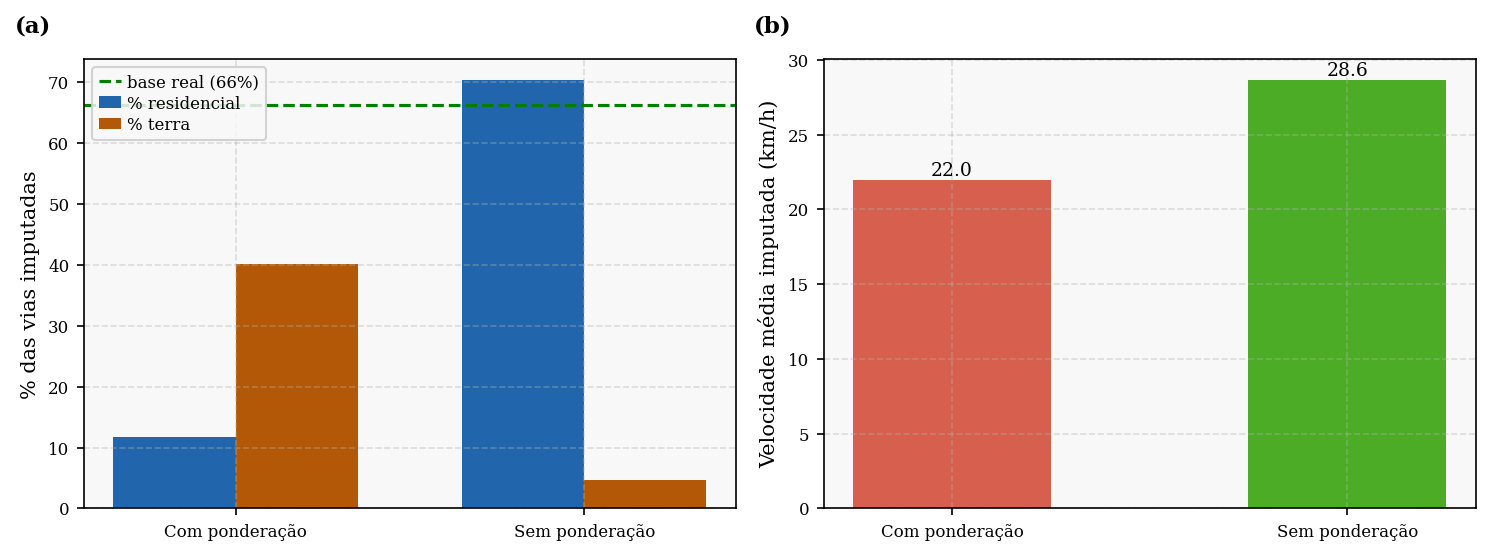

In [8]:
# ── Fig. 03 — Efeito do balanceamento na imputação ──────────────────────────
base_residential = (gdf.loc[~gdf["is_alvo"], "class"] == "residential").mean() * 100
cfgs = ["GNN com ponderação", "GNN sem ponderação"]
rotulos = ["Com ponderação", "Sem ponderação"]
x = np.arange(2); largura = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

# Painel A: distribuição imputada vs. base real
ax1.bar(x - largura/2, [comparacao[c]["% residential"] for c in cfgs], largura,
        label="% residencial", color="#2166AC")
ax1.bar(x + largura/2, [comparacao[c]["% track"] for c in cfgs], largura,
        label="% terra", color="#B35806")
ax1.axhline(base_residential, ls="--", color="green",
            label=f"base real ({base_residential:.0f}%)")
ax1.set_xticks(x); ax1.set_xticklabels(rotulos)
ax1.set_ylabel("% das vias imputadas"); ax1.legend(fontsize=8)

# Painel B: impacto na velocidade
ax2.bar(x, [comparacao[c]["vel_média_alvos"] for c in cfgs], 0.5,
        color=["#D6604D", "#4DAC26"])
for i, c in enumerate(cfgs):
    ax2.text(i, comparacao[c]["vel_média_alvos"] + 0.3,
             f"{comparacao[c]['vel_média_alvos']:.1f}", ha="center", fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(rotulos)
ax2.set_ylabel("Velocidade média imputada (km/h)")

# Identificadores de painel (a) e (b)
ax1.text(-0.05, 1.05, "(a)", transform=ax1.transAxes, fontweight="bold", fontsize=11, va="bottom", ha="right")
ax2.text(-0.05, 1.05, "(b)", transform=ax2.transAxes, fontweight="bold", fontsize=11, va="bottom", ha="right")
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb022_fig03_efeito_balanceamento.png", dpi=300, bbox_inches="tight")
plt.show()

### Decisão metodológica

A ponderação eleva o F1 macro de forma marginal, mas faz a imputação prever apenas ~12%
de vias residenciais (contra 66% reais) e inflar vias de terra (`track`) para ~38%,
rebaixando a velocidade média dos trechos imputados. Como a finalidade da imputação é
estimar realisticamente a classe — e, por consequência, a velocidade — para o cálculo de
acessibilidade, **adota-se o modelo sem ponderação**, que preserva a distribuição empírica
das classes e produz velocidades coerentes.

## 6. Comparação com o baseline (GraphSAGE × Random Forest)

Confronto do modelo final (GraphSAGE sem ponderação) com o Random Forest pelo F1-score (macro e ponderado), justificando metodologicamente a escolha do modelo.

In [9]:
# ── 6. COMPARAÇÃO COM O BASELINE (GNN sem ponderação × Random Forest) ───────
# RF treinado no MESMO split, sem ponderação, para comparação justa
rf_final = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_final.fit(X_scaled[idx_treino], y[idx_treino])
pred_rf = rf_final.predict(X_scaled)

tabela_modelos = pd.DataFrame({
    "Random Forest (baseline)": {
        "F1_macro": f1_score(y[idx_teste], pred_rf[idx_teste], average="macro"),
        "F1_weighted": f1_score(y[idx_teste], pred_rf[idx_teste], average="weighted")},
    "GraphSAGE (final)": {
        "F1_macro": f1_score(y[idx_teste], pred_sem[idx_teste], average="macro"),
        "F1_weighted": f1_score(y[idx_teste], pred_sem[idx_teste], average="weighted")},
}).round(3)
print("--- Desempenho no conjunto de teste ---")
print(tabela_modelos.to_string())
print("\n✅ A GNN supera o baseline no F1 weighted, confirmando o ganho do contexto de rede.")

--- Desempenho no conjunto de teste ---
             Random Forest (baseline)  GraphSAGE (final)
F1_macro                        0.262              0.250
F1_weighted                     0.642              0.666

✅ A GNN supera o baseline no F1 weighted, confirmando o ganho do contexto de rede.


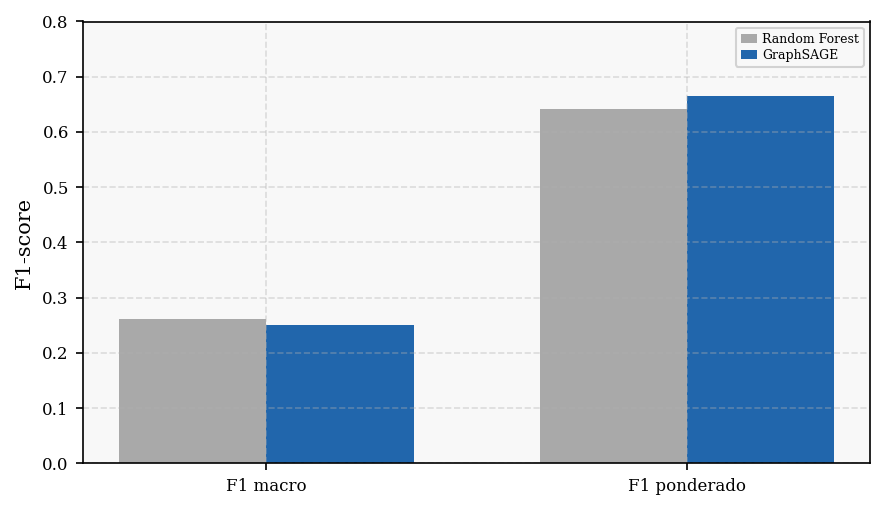

In [10]:
# ── Fig. 04 — Desempenho: baseline vs. modelo final ─────────────────────────
metricas = ["F1_macro", "F1_weighted"]; x = np.arange(2); largura = 0.35

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(x - largura/2, [tabela_modelos["Random Forest (baseline)"][m] for m in metricas],
       largura, label="Random Forest", color="#A9A9A9")
ax.bar(x + largura/2, [tabela_modelos["GraphSAGE (final)"][m] for m in metricas],
       largura, label="GraphSAGE", color="#2166AC")
ax.set_xticks(x); ax.set_xticklabels(["F1 macro", "F1 ponderado"])
ax.set_ylabel("F1-score"); ax.set_ylim(0, 0.8); ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb022_fig04_comparacao_modelos.png", dpi=300,bbox_inches="tight")
plt.show()

## 7. Imputação e exportação

Aplicamos o modelo final apenas às vias-alvo, preservando intactas as classes já
conhecidas e a coluna `classe_original` (auditoria, vinda do NB 02.1). O grafo enriquecido
é salvo para o cálculo de impedâncias (NB 03).

In [11]:
# ── 7. IMPUTAÇÃO SELETIVA E EXPORTAÇÃO ──────────────────────────────────────
gdf["class_imputada"] = gdf["class"].astype(str)
classes_previstas = encoder.inverse_transform(pred_sem)
gdf.loc[gdf["is_alvo"], "class_imputada"] = classes_previstas[gdf["is_alvo"].values]

n = int(gdf["is_alvo"].sum())
print(f"🎯 {n:,} vias imputadas. Distribuição:")
print(gdf.loc[gdf["is_alvo"], "class_imputada"].value_counts().head(8).to_string())

# Remove colunas auxiliares de modelagem antes de exportar
saida = gdf.drop(columns=["is_alvo"], errors="ignore")
caminho = INT_GRAFO / "zonaUrbana_5km_road_imputed.parquet"
saida.to_parquet(caminho)
print(f"\n💾 Grafo imputado salvo: {caminho} ({len(saida):,} arestas)")

🎯 1,640 vias imputadas. Distribuição:
class_imputada
residential    1153
service         333
track            76
primary          42
secondary        14
trunk             9
tertiary          7
footway           4

💾 Grafo imputado salvo: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\intermediarios\02_grafo\zonaUrbana_5km_road_imputed.parquet (52,977 arestas)


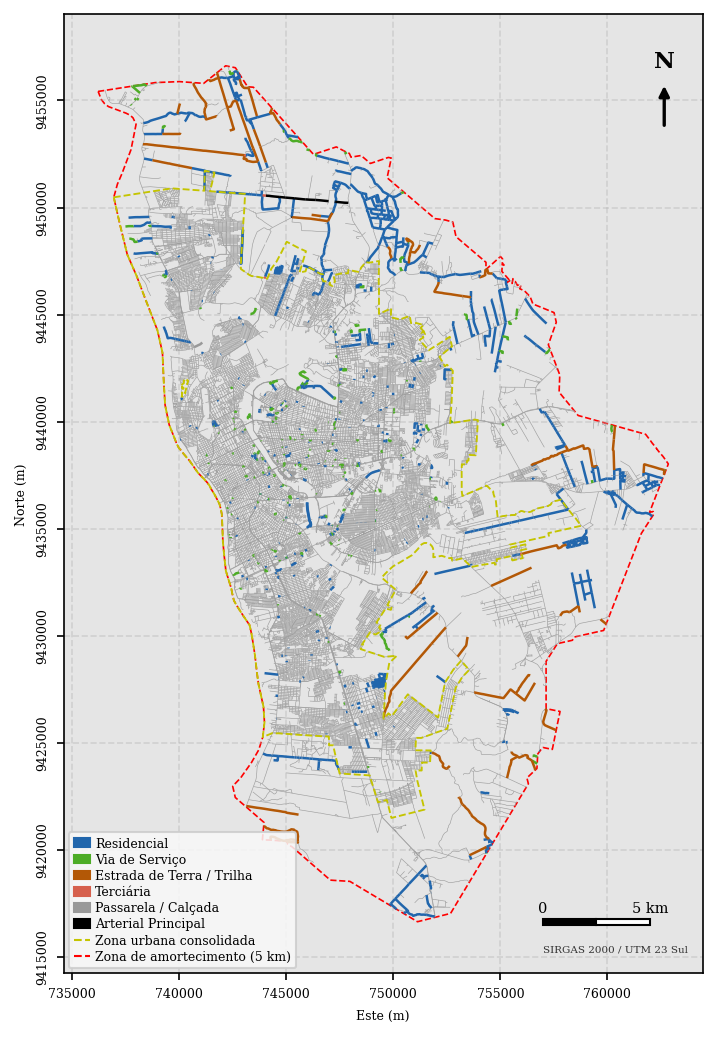

In [12]:
# ── Fig. 05 — Distribuição espacial das vias imputadas ──────────────────────
FONTE_LEGENDA = 6
FONTE_EIXOS   = 6
FONTE_CRS     = 5

zona_urbana = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
area_estudo = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO)
CORES_CLASSE = {"residential": "#2166AC", "service": "#4DAC26", "track": "#B35806",
                "living_street": "#762A83", "tertiary": "#D6604D", "footway": "#999999",
                "path": "#8C510A", "trunk": "#000000"}
traducao_classes = {
    "motorway": "Via Expressa", "trunk": "Arterial Principal", "primary": "Primária",
    "secondary": "Secundária", "tertiary": "Terciária", "residential": "Residencial",
    "living_street": "Via Compartilhada", "pedestrian": "Uso Exclusivo de Pedestres",
    "footway": "Passarela / Calçada", "path": "Caminho / Trilha",
    "track": "Estrada de Terra / Trilha", "service": "Via de Serviço",
    "cycleway": "Ciclovia", "steps": "Escada", "road": "Via Genérica (não especificada)",
    "unclassified": "Não classificada", "unknown": "Desconhecida",
}

fig, ax = plt.subplots(figsize=(5.8, 8.3))
ax.set_facecolor("#E5E5E5")

area_estudo.boundary.plot(ax=ax, color="#FF0000", ls="--", lw=0.8, zorder=1)
gdf[~gdf["is_alvo"]].plot(ax=ax, color="#9E9E9E", linewidth=0.3, zorder=2)

imputadas = gdf[gdf["is_alvo"]]

for classe, cor in CORES_CLASSE.items():
    sub = imputadas[imputadas["class_imputada"] == classe]
    if len(sub): sub.plot(ax=ax, color=cor, linewidth=1.2, zorder=3)

zona_urbana.boundary.plot(ax=ax, color="#C4C400", ls="--", lw=0.9, zorder=4)

ax.legend(
    handles=[Patch(color=c, label=traducao_classes.get(cl, cl)) for cl, c in CORES_CLASSE.items()
             if (imputadas["class_imputada"] == cl).any()]
            + [Line2D([], [], color="#C4C400", ls="--", lw=1, label="Zona urbana consolidada"),
               Line2D([], [], color="#FF0000", ls="--", lw=1, label="Zona de amortecimento (5 km)")],
    loc="lower left",
    fontsize=FONTE_LEGENDA, title_fontsize=7,
    labelspacing=0.25, handlelength=1.3, handletextpad=0.4,
    borderpad=0.4, borderaxespad=0.4, framealpha=0.85,
)

ajustar_zoom_camada(ax, area_estudo, margem=0.06)
formatar_eixos_mapa(ax, fontsize=FONTE_EIXOS)

barra_escala(ax, frac_x=0.75, frac_y=0.05)
seta_norte(ax)

x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
ax.text(x0 + (x1 - x0) * 0.75, y0 + (y1 - y0) * 0.02,
        "SIRGAS 2000 / UTM 23 Sul", ha="left", va="bottom",
        fontsize=FONTE_CRS, color="#333333", zorder=10)

fig.savefig(FIGURAS_NB / "nb022_fig05_mapa_imputadas.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Refinamento de continuidade funcional

A inspeção da malha classificada revelou **descontinuidades funcionais pontuais** herdadas
da base colaborativa: corredores contínuos (avenidas com um mesmo logradouro) apresentam,
em trechos curtos, segmentos de classe muito inferior — por exemplo, um trecho
`residential` de poucos metros no meio de uma via `primary`. Essas rupturas criam
**gargalos artificiais de velocidade** que enviesariam as impedâncias (NB 03).

Com base no princípio da **boa continuação** de redes viárias (*strokes*), aplica-se uma
correção **conservadora e auditável**, posterior à imputação. Só são corrigidos casos de
alta confiança, que satisfazem *todos* os critérios: o segmento (i) pertence a um corredor
nomeado; (ii) é dirigível; (iii) está ≥2 níveis hierárquicos abaixo da classe dominante do
corredor; (iv) o corredor é coeso (dominante cobre ≥60% da extensão); e (v) é curto
(<150 m). A classe imputada original é preservada; a correção vai para uma coluna nova
(`class_final`) e para uma tabela de auditoria.

In [13]:
# ── 8. REFINAMENTO DE CONTINUIDADE FUNCIONAL ────────────────────────────────
from matplotlib.lines import Line2D

from mapeprof.config import CRS_METRICO, EXT_IBGE, TABELAS
from mapeprof.viz import barra_escala, moldura_mapa, seta_norte

# Ranking hierárquico (maior = via mais estruturante)
RANK = {'motorway':7,'trunk':6,'primary':5,'secondary':4,'tertiary':3,'residential':2,
        'unclassified':2,'road':2,'living_street':1,'service':1,'track':1,
        'cycleway':0,'footway':0,'path':0,'steps':0,'pedestrian':0}
DIRIGIVEIS = {'motorway','trunk','primary','secondary','tertiary','residential',
              'living_street','service','track','unclassified','road'}

classe = gdf["class_imputada"].astype(str)
gdf["rank"] = classe.map(RANK).fillna(2).astype(int)

# Classe dominante de cada corredor nomeado (ponderada por comprimento) + participação
nomeadas = gdf[gdf["nomes_vias"].notna()]
classe_dom = nomeadas.groupby("nomes_vias").apply(
    lambda s: s.groupby("class_imputada")["length_m"].sum().idxmax())
share_dom = nomeadas.groupby("nomes_vias").apply(
    lambda s: s.groupby("class_imputada")["length_m"].sum().max() / s["length_m"].sum())
gdf["classe_dom"] = gdf["nomes_vias"].map(classe_dom)
gdf["share_dom"]  = gdf["nomes_vias"].map(share_dom)
gdf["rank_dom"]   = gdf["classe_dom"].map(RANK)

# Critério conservador (todos cumulativos)
eh_anomalia = (
    gdf["nomes_vias"].notna()
    & classe.isin(DIRIGIVEIS)
    & (gdf["rank_dom"] - gdf["rank"] >= 2)   # ≥2 níveis abaixo do dominante
    & (gdf["share_dom"] >= 0.60)             # corredor coeso (≥60%)
    & (gdf["length_m"] < 150)                # trecho curto
)
print(f"🔎 {int(eh_anomalia.sum())} quebras de continuidade identificadas "
      f"({eh_anomalia.mean()*100:.2f}% da malha).")

🔎 133 quebras de continuidade identificadas (0.25% da malha).


In [14]:
# ── 8.1 AUDITORIA, CORREÇÃO E REEXPORTAÇÃO ──────────────────────────────────
auditoria = gdf.loc[eh_anomalia, ["nomes_vias", "class_imputada", "classe_dom", "length_m"]].copy()
auditoria.columns = ["via", "classe_original", "classe_corrigida", "comprimento_m"]
auditoria = auditoria.sort_values("comprimento_m")

# class_final preserva a imputação e corrige só as anomalias (rastreável)
gdf["class_final"] = classe.copy()
gdf.loc[eh_anomalia, "class_final"] = gdf.loc[eh_anomalia, "classe_dom"]

print("--- Transições aplicadas (origem → destino) ---")
print((auditoria["classe_original"] + " → " + auditoria["classe_corrigida"]).value_counts().to_string())

# Tabela de auditoria (rastreabilidade) + grafo final com 'class_final'
TABELAS.mkdir(parents=True, exist_ok=True)
auditoria.to_csv(TABELAS / "nb022_correcoes_continuidade.csv", index=False, encoding="utf-8-sig")
gdf.drop(columns=["rank", "classe_dom", "share_dom", "rank_dom"], errors="ignore").to_parquet(
    INT_GRAFO / "zonaUrbana_5km_road_imputed.parquet")
print(f"💾 Auditoria: {TABELAS / 'nb022_correcoes_continuidade.csv'}")
print("💾 Grafo reexportado com a coluna 'class_final'.")

auditoria.to_csv(TABELAS_NB / "nb022_correcoes_continuidade.csv", index=False, sep=";", encoding="utf-8-sig")

--- Transições aplicadas (origem → destino) ---
residential → secondary     78
residential → primary       24
residential → trunk         14
tertiary → primary           6
living_street → tertiary     4
service → trunk              3
service → secondary          2
secondary → trunk            2
💾 Auditoria: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\outputs\tabelas\nb022_correcoes_continuidade.csv
💾 Grafo reexportado com a coluna 'class_final'.


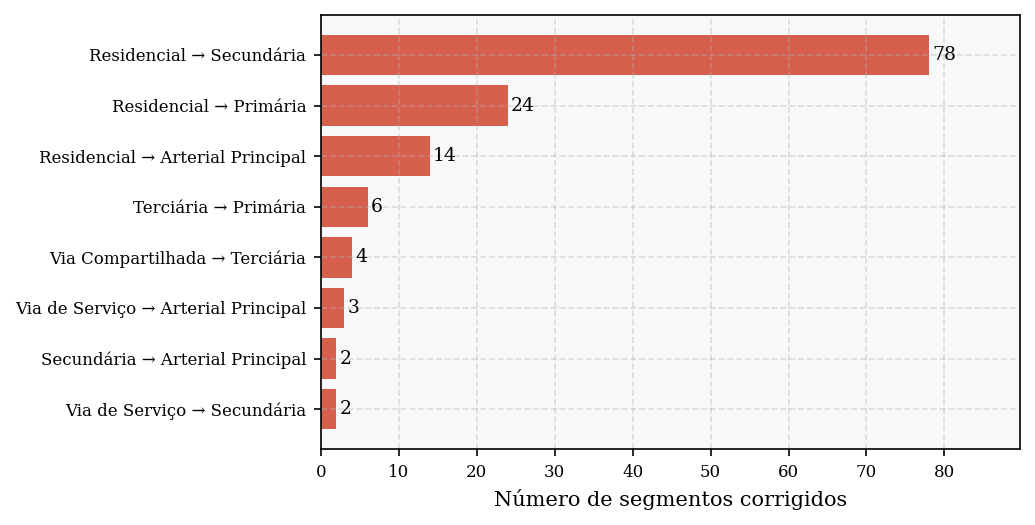

In [15]:
# ── Fig. 06 — Resumo das correções de continuidade ──────────────────────────
traducao_classes = {
    "motorway": "Via Expressa", "trunk": "Arterial Principal", "primary": "Primária",
    "secondary": "Secundária", "tertiary": "Terciária", "residential": "Residencial",
    "living_street": "Via Compartilhada", "pedestrian": "Uso Exclusivo de Pedestres",
    "footway": "Passarela / Calçada", "path": "Caminho / Trilha",
    "track": "Estrada de Terra / Trilha", "service": "Via de Serviço",
    "cycleway": "Ciclovia", "steps": "Escada", "road": "Via Genérica (não especificada)",
    "unclassified": "Não classificada", "unknown": "Desconhecida",
}
traduzir = lambda c: traducao_classes.get(str(c).lower(), str(c).title())

transicoes = (
    auditoria["classe_original"].map(traduzir) + " → " + auditoria["classe_corrigida"].map(traduzir)
).value_counts().head(8).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(transicoes.index, transicoes.values, color="#D6604D")
for i, v in enumerate(transicoes.values):
    ax.text(v + 0.4, i, str(v), va="center", fontsize=9)
ax.set_xlim(0, transicoes.max() * 1.15)
ax.set_xlabel("Número de segmentos corrigidos")
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb022_fig06_correcoes_continuidade.png", dpi=300, bbox_inches="tight")
plt.show()

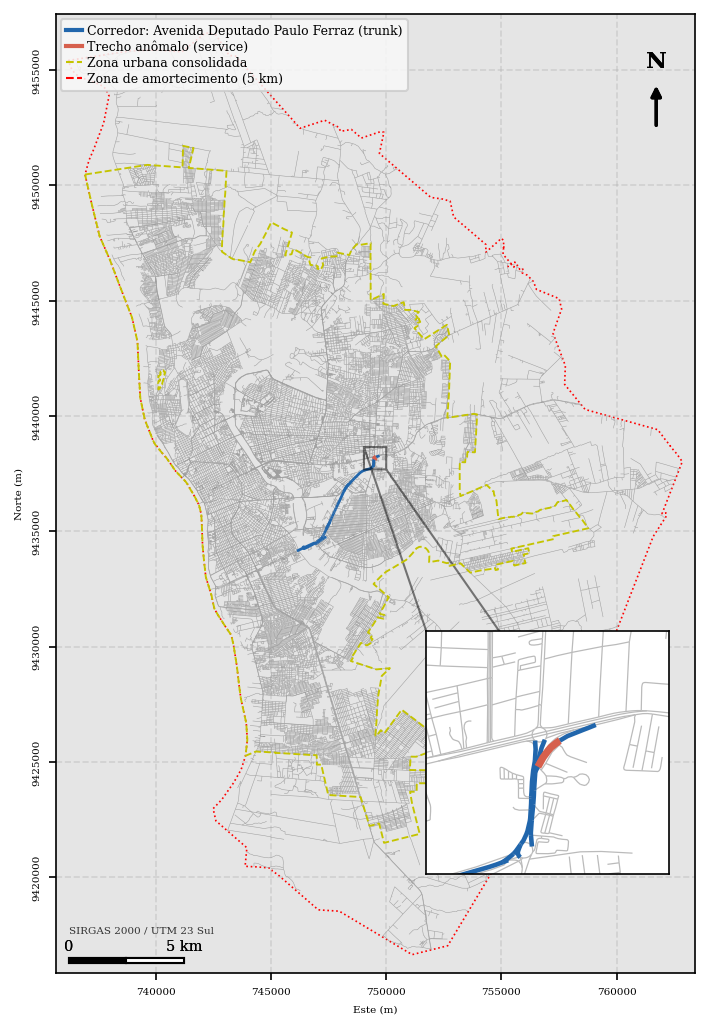

In [17]:
# ── Fig. 07 — Exemplo de quebra de continuidade (visão geral + zoom) ─────────
zona_urbana = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
area_estudo = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO)

# Exemplo mais legível: o trecho anômalo MAIS LONGO em corredor de classe alta
exemplos = auditoria[auditoria["classe_corrigida"].isin(["primary", "trunk", "secondary"])]
idx_ex = exemplos.sort_values("comprimento_m", ascending=False).index[0]
via_ex = auditoria.loc[idx_ex, "via"]
corredor = gdf[gdf["nomes_vias"] == via_ex]

seg = gdf.loc[idx_ex]
cx, cy = seg.geometry.centroid.x, seg.geometry.centroid.y
R = max(300, seg["length_m"] * 3.5)   # janela de zoom proporcional ao trecho

fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
area_estudo.boundary.plot(ax=ax, color="#FF0000", ls=":", lw=0.8, zorder=1)   # área de estudo
gdf.plot(ax=ax, color="#9E9E9E", linewidth=0.25, zorder=2)                     # rede (base)
corredor.plot(ax=ax, color="#2166AC", linewidth=1.3, zorder=3)                 # corredor
gdf.loc[[idx_ex]].plot(ax=ax, color="#D6604D", linewidth=2.5, zorder=4)        # trecho anômalo
zona_urbana.boundary.plot(ax=ax, color="#C4C400", ls="--", lw=0.9, zorder=5)     # zona urbana
ajustar_zoom_camada(ax, area_estudo, margem=0.02)

# Inset ampliado sobre o trecho anômalo
axins = ax.inset_axes([0.58, 0.04, 0.38, 0.38]); axins.set_facecolor("white")
gdf.cx[cx-R:cx+R, cy-R:cy+R].plot(ax=axins, color="#BBBBBB", linewidth=0.6)
corredor.cx[cx-R:cx+R, cy-R:cy+R].plot(ax=axins, color="#2166AC", linewidth=2.2)
gdf.loc[[idx_ex]].plot(ax=axins, color="#D6604D", linewidth=3.5)
axins.set_xlim(cx-R, cx+R); axins.set_ylim(cy-R, cy+R)
axins.set_xticks([]); axins.set_yticks([])
ax.indicate_inset_zoom(axins, edgecolor="black")

ax.legend(handles=[
    Line2D([], [], color="#2166AC", lw=2, label=f"Corredor: {via_ex} ({auditoria.loc[idx_ex,'classe_corrigida']})"),
    Line2D([], [], color="#D6604D", lw=2, label=f"Trecho anômalo ({auditoria.loc[idx_ex,'classe_original']})"),
    Line2D([], [], color="#C4C400", ls="--", lw=1, label="Zona urbana consolidada"),
    Line2D([], [], color="#FF0000", ls="--", lw=1, label="Zona de amortecimento (5 km)"),
], loc="upper left", fontsize=6, title_fontsize=7, labelspacing=0.25,
   handlelength=1.3, handletextpad=0.4, borderpad=0.4, borderaxespad=0.4, framealpha=0.85)

# moldura_mapa(ax, "", "Overture Maps (2026); IBGE (2022). Elaboração própria.")
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax); 
seta_norte(ax)

barra_escala(ax); seta_norte(ax)

x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
ax.text(x0 + (x1 - x0) * 0.02, y0 + (y1 - y0) * 0.04,
        "SIRGAS 2000 / UTM 23 Sul", ha="left", va="bottom",
        fontsize=5, color="#333333", zorder=10)

fig.savefig(FIGURAS_NB / "nb022_fig07_exemplo_continuidade.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Próximos passos
A malha está 100% classificada. O **NB 03** atribuirá velocidades por classe
(`class_imputada`) e converterá cada aresta em **minutos de viagem**, gerando as
impedâncias para as isócronas (NB 04) e o cálculo AE2SFCA (NB 05).